## 1. Setup Lingkungan

Import library utama, konfigurasi path dataset Kaggle, dan tampilkan isi direktori input.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FASE 1: PERSIAPAN DAN SETUP")
print("="*80)

# Cek isi /kaggle/input untuk memastikan nama folder dataset
print("Isi /kaggle/input:")
print(os.listdir("/kaggle/input"))

# GANTI sesuai output di atas jika perlu
dataset_path = "/kaggle/input/datasets/crawford/qureai-headct"  

working_path = "/kaggle/working/ich_project"
os.makedirs(working_path, exist_ok=True)

print(f"\nDataset Path: {dataset_path}")
print(f"Working Path: {working_path}")


FASE 1: PERSIAPAN DAN SETUP
Isi /kaggle/input:
['datasets']

Dataset Path: /kaggle/input/datasets/crawford/qureai-headct
Working Path: /kaggle/working/ich_project


## 2. DICOM Parsing & Metadata Studi

Kelas `CQ500Dataset` membaca semua file DICOM dari direktori dataset dan membangun DataFrame metadata: `study_id`, `num_slices`, `dicom_files`, dan label subtipe ICH.

In [2]:
class CQ500Dataset:

    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.df = self._build_metadata()

    def _build_metadata(self):

        study_dict = {}

        for dcm_path in self.dataset_path.rglob("*.dcm"):

            # Ambil folder seperti:
            # "CQ500CT156 CQ500CT156"
            raw_folder = dcm_path.parts[-4]

            # Ambil hanya bagian pertama (hapus duplikasi)
            clean_id = raw_folder.split()[0]

            study_dict.setdefault(clean_id, []).append(dcm_path)

        data = []

        for study_id, slices in study_dict.items():
            data.append({
                "study_id": study_id,
                "num_slices": len(slices),
                "dicom_files": sorted(
                    [str(p.relative_to(self.dataset_path)) for p in slices]
                )
            })

        return pd.DataFrame(data)


### Instansiasi Dataset & Preview

Membuat objek `CQ500Dataset` dan menampilkan jumlah studi serta 5 baris pertama metadata.

In [3]:
dataset = CQ500Dataset(dataset_path)

print("Total studies:", len(dataset.df))
print(dataset.df.head())


Total studies: 473
     study_id  num_slices                                        dicom_files
0  CQ500CT156         191  [qct03/CQ500CT156 CQ500CT156/Unknown Study/CT ...
1  CQ500CT144         320  [qct02/CQ500CT144 CQ500CT144/Unknown Study/CT ...
2   CQ500CT15         252  [qct03/CQ500CT15 CQ500CT15/Unknown Study/CT 55...
3  CQ500CT162         756  [qct03/CQ500CT162 CQ500CT162/Unknown Study/CT ...
4  CQ500CT158         581  [qct03/CQ500CT158 CQ500CT158/Unknown Study/CT ...


### Tampilkan DataFrame

Melihat 5 baris pertama DataFrame metadata dataset.

In [4]:
dataset.df.head()

,study_id,num_slices,dicom_files
0,CQ500CT156,191,[qct03/CQ500CT156 CQ500CT156/Unknown Study/CT ...
1,CQ500CT144,320,[qct02/CQ500CT144 CQ500CT144/Unknown Study/CT ...
2,CQ500CT15,252,[qct03/CQ500CT15 CQ500CT15/Unknown Study/CT 55...
3,CQ500CT162,756,[qct03/CQ500CT162 CQ500CT162/Unknown Study/CT ...
4,CQ500CT158,581,[qct03/CQ500CT158 CQ500CT158/Unknown Study/CT ...


## 3. Load Label CSV (Reads)

Memuat file `reads.csv` dari dataset QureAI yang berisi penilaian 3 radiolog (R1, R2, R3) untuk ICH dan subtipenya per studi.

In [5]:
import pandas as pd

labels_df = pd.read_csv("/kaggle/input/datasets/crawford/qureai-headct/reads.csv")

print("Shape:", labels_df.shape)
print(labels_df.columns)


Shape: (491, 44)
Index(['name', 'Category', 'R1:ICH', 'R1:IPH', 'R1:IVH', 'R1:SDH', 'R1:EDH',
       'R1:SAH', 'R1:BleedLocation-Left', 'R1:BleedLocation-Right',
       'R1:ChronicBleed', 'R1:Fracture', 'R1:CalvarialFracture',
       'R1:OtherFracture', 'R1:MassEffect', 'R1:MidlineShift', 'R2:ICH',
       'R2:IPH', 'R2:IVH', 'R2:SDH', 'R2:EDH', 'R2:SAH',
       'R2:BleedLocation-Left', 'R2:BleedLocation-Right', 'R2:ChronicBleed',
       'R2:Fracture', 'R2:CalvarialFracture', 'R2:OtherFracture',
       'R2:MassEffect', 'R2:MidlineShift', 'R3:ICH', 'R3:IPH', 'R3:IVH',
       'R3:SDH', 'R3:EDH', 'R3:SAH', 'R3:BleedLocation-Left',
       'R3:BleedLocation-Right', 'R3:ChronicBleed', 'R3:Fracture',
       'R3:CalvarialFracture', 'R3:OtherFracture', 'R3:MassEffect',
       'R3:MidlineShift'],
      dtype='object')


### Preview Label CSV

Melihat 5 baris pertama dari `reads.csv` untuk memahami struktur data anotasi.

In [6]:
labels_df.head()

,name,Category,R1:ICH,R1:IPH,R1:IVH,R1:SDH,R1:EDH,R1:SAH,R1:BleedLocation-Left,R1:BleedLocation-Right,...,R3:EDH,R3:SAH,R3:BleedLocation-Left,R3:BleedLocation-Right,R3:ChronicBleed,R3:Fracture,R3:CalvarialFracture,R3:OtherFracture,R3:MassEffect,R3:MidlineShift
0,CQ500-CT-427,B2,1,1,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,0
1,CQ500-CT-181,B2,1,1,0,1,0,1,1,0,...,1,1,1,0,0,1,1,0,1,1
2,CQ500-CT-99,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CQ500-CT-47,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CQ500-CT-195,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Distribusi Jumlah Slice per Studi

Histogram untuk melihat rentang dan persebaran jumlah slice antar studi.

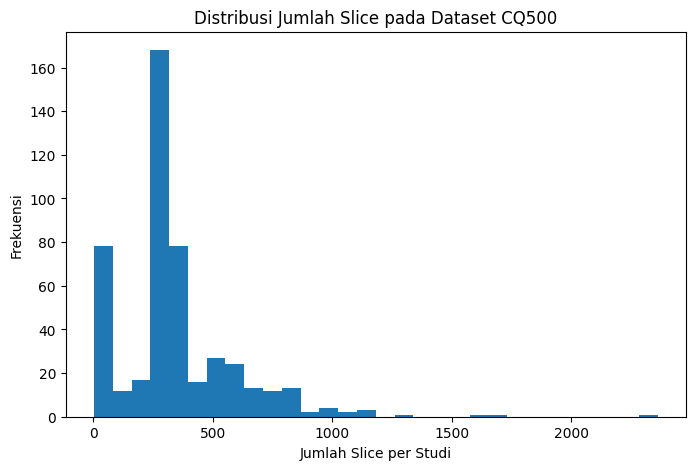

In [7]:

plt.figure(figsize=(8,5))
plt.hist(dataset.df["num_slices"], bins=30)
plt.xlabel("Jumlah Slice per Studi")
plt.ylabel("Frekuensi")
plt.title("Distribusi Jumlah Slice pada Dataset CQ500")
plt.show()

## 4. Konstruksi Label via Majority Voting

Membuat label biner untuk `Any_ICH` dan setiap subtipe (IPH, IVH, SDH, EDH, SAH) menggunakan majority voting dari ketiga radiolog.

In [8]:
labels_df.columns = labels_df.columns.str.strip()

print("Total studi di CSV:", len(labels_df))


# --------------------------------------------------------------------------
# 1. Definisikan subtipe
# --------------------------------------------------------------------------

subtypes = ["ICH", "IPH", "IVH", "SDH", "EDH", "SAH"]


# --------------------------------------------------------------------------
# 2. Majority voting: positif jika ≥2 radiolog memberi label 1
# --------------------------------------------------------------------------

for subtype in subtypes:
    
    r1 = f"R1:{subtype}"
    r2 = f"R2:{subtype}"
    r3 = f"R3:{subtype}"
    
    labels_df[subtype] = (
        labels_df[[r1, r2, r3]].sum(axis=1) >= 2
    ).astype(int)


# --------------------------------------------------------------------------
# 3. Definisi Any-ICH (Persamaan 4.2)
# y_any = max(IPH, IVH, SDH, EDH, SAH)
# --------------------------------------------------------------------------

labels_df["Any_ICH"] = labels_df[
    ["IPH", "IVH", "SDH", "EDH", "SAH"]
].max(axis=1)


# --------------------------------------------------------------------------
# 4. Sinkronisasi ID dengan folder DICOM
# --------------------------------------------------------------------------

# Ubah format dataset ID menjadi format CSV
dataset.df["study_id_csv_format"] = dataset.df["study_id"].apply(
    lambda x: x.replace("CQ500CT", "CQ500-CT-")
)

# Pastikan kolom name di CSV bersih
labels_df["name_clean"] = labels_df["name"].str.strip()

# Merge
dataset.df = dataset.df.merge(
    labels_df,
    left_on="study_id_csv_format",
    right_on="name_clean",
    how="inner"
)

print("Jumlah studi setelah merge:", len(dataset.df))


# --------------------------------------------------------------------------
# 5. Verifikasi distribusi kelas
# --------------------------------------------------------------------------

print("\nDistribusi Any-ICH:")
print(dataset.df["Any_ICH"].value_counts())

print("\nDistribusi Subtipe:")
for subtype in ["IPH","IVH","SDH","EDH","SAH"]:
    print(f"{subtype}: {dataset.df[subtype].sum()}")

Total studi di CSV: 491
Jumlah studi setelah merge: 473

Distribusi Any-ICH:
Any_ICH
0    282
1    191
Name: count, dtype: int64

Distribusi Subtipe:
IPH: 129
IVH: 26
SDH: 49
EDH: 12
SAH: 57


## 5. Visualisasi Kesepakatan Radiolog

Histogram tingkat kesepakatan antar radiolog untuk menilai konsistensi anotasi.

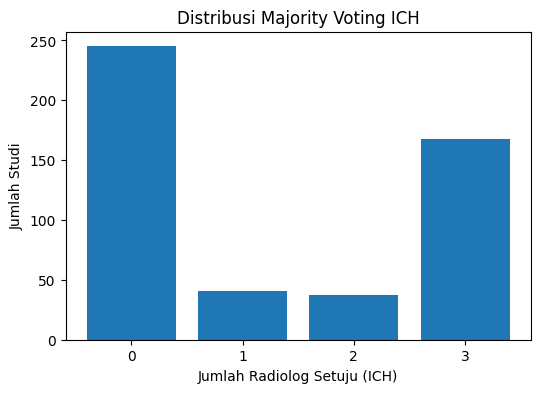

In [9]:

agreement_counts = []

for idx, row in labels_df.iterrows():
    votes = row[["R1:ICH","R2:ICH","R3:ICH"]].sum()
    agreement_counts.append(votes)

plt.figure(figsize=(6,4))
plt.hist(agreement_counts, bins=[0,1,2,3,4], align="left", rwidth=0.8)
plt.xlabel("Jumlah Radiolog Setuju (ICH)")
plt.ylabel("Jumlah Studi")
plt.title("Distribusi Majority Voting ICH")
plt.xticks([0,1,2,3])
plt.show()


### Simpan Labeled Metadata

Menyimpan DataFrame yang sudah memiliki label hasil majority voting ke file `.pkl`.

In [10]:

# save_dir = "/kaggle/working/cache"
# os.makedirs(save_dir, exist_ok=True)

# labeled_metadata_path = os.path.join(save_dir, "cq500_labeled_metadata.pkl")

# with open(labeled_metadata_path, "wb") as f:
#     pickle.dump(dataset.df, f)

# print("✓ Labeled metadata disimpan di:", labeled_metadata_path)
# print("Ukuran file (MB):", round(os.path.getsize(labeled_metadata_path)/1e6, 2))


### (Diarsipkan) Load Metadata

Blok kode load metadata yang dikomentari — gunakan jika file `.pkl` sudah tersedia.

In [11]:
# with open(labeled_metadata_path, "rb") as f:
#     df_labeled = pickle.load(f)

# print("Total studies:", len(df_labeled))

### Heatmap Korelasi Antar Subtipe ICH

Heatmap korelasi Pearson antar subtipe ICH untuk melihat hubungan ko-morbiditas.

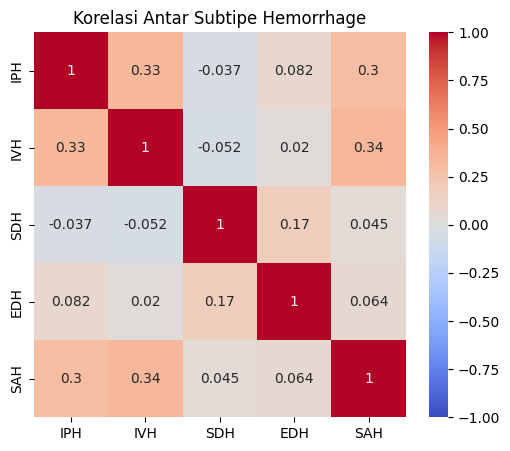

In [12]:
import numpy as np

subtype_matrix = dataset.df[["IPH","IVH","SDH","EDH","SAH"]]

corr_matrix = subtype_matrix.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Antar Subtipe Hemorrhage")
plt.show()


## 7. Definisi Eksperimen

Kelas `ExperimentBuilder` mendefinisikan 6 eksperimen klasifikasi biner berdasarkan jenis ICH: `any_ich`, `IPH`, `IVH`, `SDH`, `EDH`, `SAH`.

In [13]:
class ExperimentBuilder:
    
    def __init__(self, df):
        self.df = df.copy()
    
    def any_ich(self):
        df = self.df.copy()
        df["label"] = df["Any_ICH"]
        return df
    
    def subtype_vs_normal(self, subtype):
        
        positive = self.df[self.df[subtype] == 1].copy()
        
        negative = self.df[
            (self.df[["IPH","IVH","SDH","EDH","SAH"]].sum(axis=1) == 0)
        ].copy()
        
        df = pd.concat([positive, negative], ignore_index=True)
        df["label"] = df[subtype]
        
        return df.reset_index(drop=True)


builder = ExperimentBuilder(dataset.df)

experiments = {
    "any_ich": builder.any_ich(),
    "iph": builder.subtype_vs_normal("IPH"),
    "sdh": builder.subtype_vs_normal("SDH"),
    "sah": builder.subtype_vs_normal("SAH")
}


## 8. Distribusi Kelas per Eksperimen

Menampilkan jumlah sampel positif/negatif per eksperimen dan visualisasi bar chart perbandingannya.

In [14]:
print("\nDistribusi kelas per eksperimen:")

for name, df_exp in experiments.items():
    pos = df_exp["label"].sum()
    neg = len(df_exp) - pos
    
    print(f"\n{name.upper()}")
    print("Total:", len(df_exp))
    print("Positif:", pos)
    print("Normal:", neg)



Distribusi kelas per eksperimen:

ANY_ICH
Total: 473
Positif: 191
Normal: 282

IPH
Total: 411
Positif: 129
Normal: 282

SDH
Total: 331
Positif: 49
Normal: 282

SAH
Total: 339
Positif: 57
Normal: 282


### Bar Chart Distribusi Kelas

Visualisasi perbandingan jumlah positif vs negatif untuk semua eksperimen.

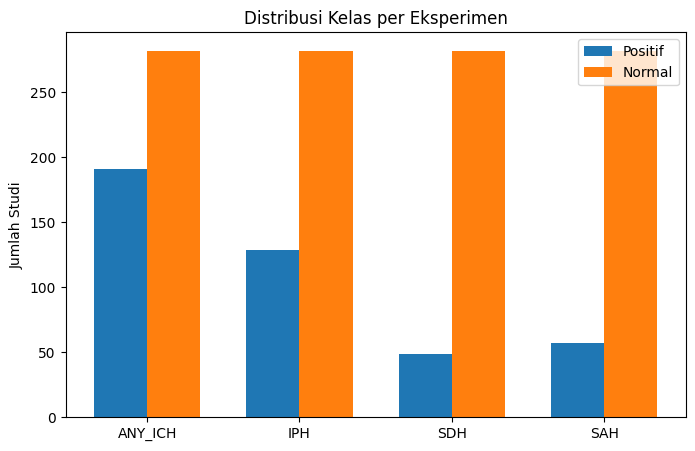

In [15]:
import numpy as np

labels_plot = []
positives = []
negatives = []

for name, df_exp in experiments.items():
    labels_plot.append(name.upper())
    positives.append(df_exp["label"].sum())
    negatives.append(len(df_exp) - df_exp["label"].sum())

x = np.arange(len(labels_plot))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, positives, width, label="Positif")
plt.bar(x + width/2, negatives, width, label="Normal")

plt.xticks(x, labels_plot)
plt.ylabel("Jumlah Studi")
plt.title("Distribusi Kelas per Eksperimen")
plt.legend()
plt.show()


## Analisis Dataset Lanjutan

Bagian ini menyajikan statistik deskriptif mendalam tentang dataset CQ500 untuk memahami karakteristik setiap subtipe ICH sebelum proses training dimulai.

### Tabel Statistik Ringkasan per Subtipe

Tabel berikut menampilkan jumlah kasus positif/negatif, tingkat prevalensi, dan rata-rata jumlah slice untuk setiap subtipe ICH.

In [16]:
import pandas as pd
import numpy as np

# Tabel statistik per subtipe
summary_rows = []
for subtype in ["Any_ICH", "IPH", "IVH", "SDH", "EDH", "SAH"]:
    pos = dataset.df[dataset.df[subtype] == 1]
    neg = dataset.df[dataset.df[subtype] == 0]
    summary_rows.append({
        "Subtipe": subtype,
        "Total Studi": len(dataset.df),
        "Positif": len(pos),
        "Negatif": len(neg),
        "Prevalensi (%)": round(len(pos) / len(dataset.df) * 100, 1),
        "Avg Slice (Pos)": round(pos["num_slices"].mean(), 1) if len(pos) > 0 else 0,
        "Avg Slice (Neg)": round(neg["num_slices"].mean(), 1) if len(neg) > 0 else 0,
    })

df_summary_stats = pd.DataFrame(summary_rows).set_index("Subtipe")
print(df_summary_stats.to_string())
df_summary_stats

         Total Studi  Positif  Negatif  Prevalensi (%)  Avg Slice (Pos)  Avg Slice (Neg)
Subtipe                                                                                 
Any_ICH          473      191      282            40.4            350.0            349.0
IPH              473      129      344            27.3            361.9            344.7
IVH              473       26      447             5.5            298.5            352.4
SDH              473       49      424            10.4            304.0            354.7
EDH              473       12      461             2.5            331.2            349.9
SAH              473       57      416            12.1            381.8            345.0


,Total Studi,Positif,Negatif,Prevalensi (%),Avg Slice (Pos),Avg Slice (Neg)
Subtipe,,,,,,
Any_ICH,473,191,282,40.4,350.0,349.0
IPH,473,129,344,27.3,361.9,344.7
IVH,473,26,447,5.5,298.5,352.4
SDH,473,49,424,10.4,304.0,354.7
EDH,473,12,461,2.5,331.2,349.9
SAH,473,57,416,12.1,381.8,345.0


### Co-occurrence Matrix Antar Subtipe

Matrix ini menunjukkan berapa banyak pasien memiliki **lebih dari satu subtipe ICH secara bersamaan** (komorbiditas). Nilai diagonal menunjukkan total kasus positif tiap subtipe.

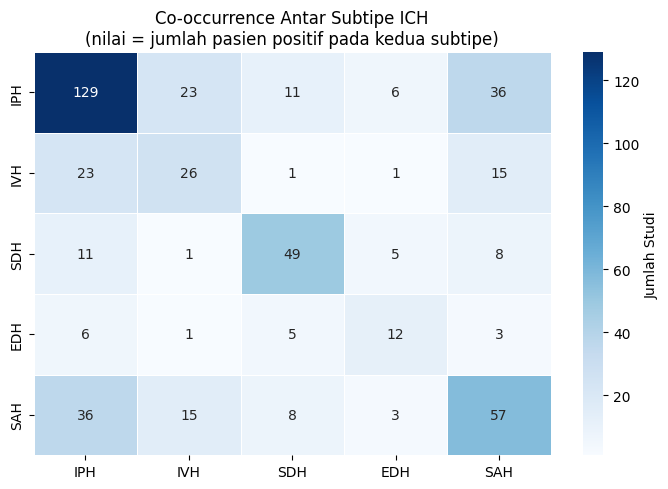

In [17]:
subtypes_list = ["IPH", "IVH", "SDH", "EDH", "SAH"]
cooccurrence = pd.DataFrame(0, index=subtypes_list, columns=subtypes_list)

for i in subtypes_list:
    for j in subtypes_list:
        cooccurrence.loc[i, j] = int(
            ((dataset.df[i] == 1) & (dataset.df[j] == 1)).sum()
        )

plt.figure(figsize=(7, 5))
sns.heatmap(
    cooccurrence, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, cbar_kws={"label": "Jumlah Studi"}
)
plt.title("Co-occurrence Antar Subtipe ICH\n(nilai = jumlah pasien positif pada kedua subtipe)", fontsize=12)
plt.tight_layout()
plt.show()

### Distribusi Jumlah Slice: Kasus Positif vs Negatif

Perbandingan distribusi jumlah slice antara studi yang mengandung ICH dan yang normal untuk tiga subtipe utama.

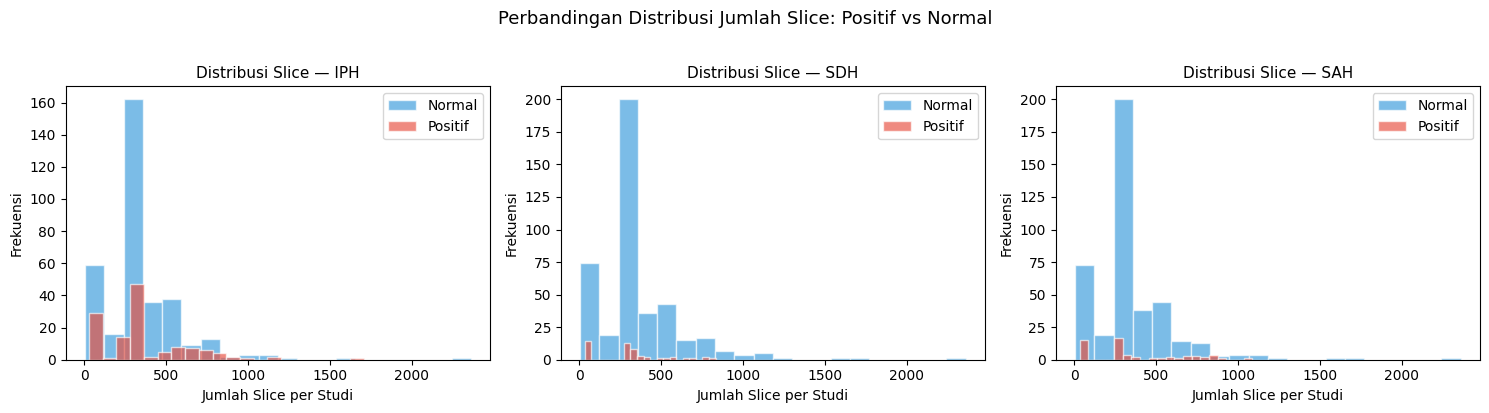

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_subtypes = ["IPH", "SDH", "SAH"]
colors = {1: "#e74c3c", 0: "#3498db"}
labels_map = {1: "Positif", 0: "Normal"}

for ax, subtype in zip(axes, plot_subtypes):
    for lbl in [0, 1]:
        grp = dataset.df[dataset.df[subtype] == lbl]
        ax.hist(
            grp["num_slices"], bins=20, alpha=0.65,
            color=colors[lbl], label=labels_map[lbl], edgecolor="white"
        )
    ax.set_title(f"Distribusi Slice — {subtype}", fontsize=11)
    ax.set_xlabel("Jumlah Slice per Studi")
    ax.set_ylabel("Frekuensi")
    ax.legend()

plt.suptitle("Perbandingan Distribusi Jumlah Slice: Positif vs Normal", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Stratified Split (70 / 15 / 15)

Kelas `DataSplitter` membagi data secara stratified di level pasien: 70% train, 15% val, 15% test. Splits disimpan per eksperimen.

In [19]:
from sklearn.model_selection import train_test_split

class DataSplitter:
    
    def __init__(self, seed=42):
        self.seed = seed
    
    def split(self, df):
        
        train_df, temp_df = train_test_split(
            df,
            test_size=0.30,
            stratify=df["label"],
            random_state=self.seed
        )
        
        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["label"],
            random_state=self.seed
        )
        
        return train_df, val_df, test_df


splitter = DataSplitter(seed=42)

splits = {}

for name, df_exp in experiments.items():
    
    train_df, val_df, test_df = splitter.split(df_exp)
    
    splits[name] = {
        "train": train_df,
        "val": val_df,
        "test": test_df
    }
    
    print(f"\n{name.upper()}")
    print("Train:", len(train_df))
    print("Val:", len(val_df))
    print("Test:", len(test_df))



ANY_ICH
Train: 331
Val: 71
Test: 71

IPH
Train: 287
Val: 62
Test: 62

SDH
Train: 231
Val: 50
Test: 50

SAH
Train: 237
Val: 51
Test: 51


### Simpan Splits

Menyimpan hasil split train/val/test ke file `.pkl` untuk digunakan kembali.

In [20]:
# splits_path = os.path.join(save_dir, "cq500_splits.pkl")

# with open(splits_path, "wb") as f:
#     pickle.dump(splits, f)

# print("✓ Splits disimpan di:", splits_path)
# print("Ukuran file (MB):", round(os.path.getsize(splits_path)/1e6, 2))

### (Diarsipkan) Load Splits

Blok kode load splits yang dikomentari — aktifkan jika splits sudah tersedia.

In [21]:
# with open("/kaggle/input/your-cache-dataset/splits.pkl", "rb") as f:
#     splits = pickle.load(f)

# print("Splits loaded successfully")

## 10. Cek Data Leakage

Memastikan tidak ada `study_id` yang tumpang tindih antar split train/val/test, lalu menampilkan distribusi kelas per subset.

In [22]:
def check_leakage(train_df, val_df, test_df):
    
    train_ids = set(train_df["study_id"])
    val_ids = set(val_df["study_id"])
    test_ids = set(test_df["study_id"])
    
    assert len(train_ids & val_ids) == 0
    assert len(train_ids & test_ids) == 0
    assert len(val_ids & test_ids) == 0

for name, split_data in splits.items():
    check_leakage(
        split_data["train"],
        split_data["val"],
        split_data["test"]
    )

print("\n✓ Tidak ada patient overlap antar subset")



✓ Tidak ada patient overlap antar subset


### Distribusi Kelas per Split

Menampilkan jumlah positif dan total per subset (train/val/test) untuk setiap eksperimen.

In [23]:
for exp_name, split_data in splits.items():
    
    print("\n", exp_name.upper())
    
    for subset in ["train","val","test"]:
        df_subset = split_data[subset]
        pos = df_subset["label"].sum()
        total = len(df_subset)
        print(f"{subset}: Positif {pos}/{total}")



 ANY_ICH
train: Positif 134/331
val: Positif 29/71
test: Positif 28/71

 IPH
train: Positif 90/287
val: Positif 20/62
test: Positif 19/62

 SDH
train: Positif 34/231
val: Positif 8/50
test: Positif 7/50

 SAH
train: Positif 40/237
val: Positif 9/51
test: Positif 8/51


## Analisis Hasil Pembagian Data (Train / Val / Test)

Bagian ini memverifikasi bahwa stratified split berhasil mempertahankan proporsi kelas yang konsisten di seluruh subset data.

### Tabel Ringkasan Lengkap Semua Split

Menampilkan jumlah studi, kasus positif/negatif, rasio imbalance, dan prevalensi untuk setiap kombinasi eksperimen dan split.

In [24]:
rows = []
for exp_name, split_data in splits.items():
    for subset in ["train", "val", "test"]:
        df_sub = split_data[subset]
        pos = int(df_sub["label"].sum())
        total = len(df_sub)
        neg = total - pos
        rows.append({
            "Eksperimen": exp_name.upper(),
            "Split": subset,
            "Total": total,
            "Positif": pos,
            "Negatif": neg,
            "Rasio Imbalance": round(neg / pos, 2) if pos > 0 else float("inf"),
            "Prevalensi (%)": round(pos / total * 100, 1),
        })

df_split_summary = pd.DataFrame(rows)
print(df_split_summary.to_string(index=False))
df_split_summary

Eksperimen Split  Total  Positif  Negatif  Rasio Imbalance  Prevalensi (%)
   ANY_ICH train    331      134      197             1.47            40.5
   ANY_ICH   val     71       29       42             1.45            40.8
   ANY_ICH  test     71       28       43             1.54            39.4
       IPH train    287       90      197             2.19            31.4
       IPH   val     62       20       42             2.10            32.3
       IPH  test     62       19       43             2.26            30.6
       SDH train    231       34      197             5.79            14.7
       SDH   val     50        8       42             5.25            16.0
       SDH  test     50        7       43             6.14            14.0
       SAH train    237       40      197             4.92            16.9
       SAH   val     51        9       42             4.67            17.6
       SAH  test     51        8       43             5.38            15.7


,Eksperimen,Split,Total,Positif,Negatif,Rasio Imbalance,Prevalensi (%)
0,ANY_ICH,train,331,134,197,1.47,40.5
1,ANY_ICH,val,71,29,42,1.45,40.8
2,ANY_ICH,test,71,28,43,1.54,39.4
3,IPH,train,287,90,197,2.19,31.4
4,IPH,val,62,20,42,2.10,32.3
5,IPH,test,62,19,43,2.26,30.6
6,SDH,train,231,34,197,5.79,14.7
7,SDH,val,50,8,42,5.25,16.0
8,SDH,test,50,7,43,6.14,14.0
9,SAH,train,237,40,197,4.92,16.9


### Visualisasi Distribusi Kelas per Split

Stacked bar chart yang menunjukkan proporsi positif (merah) dan negatif (biru) di setiap subset untuk setiap eksperimen.

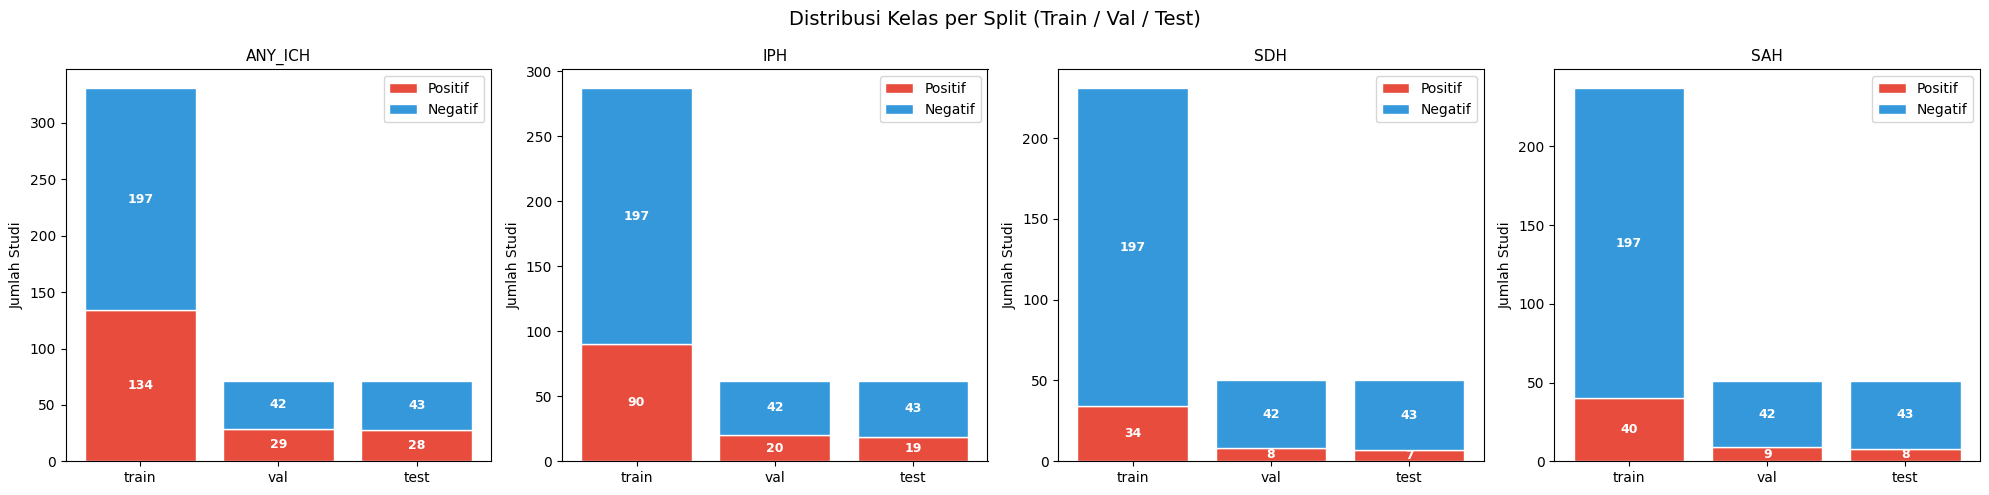

In [25]:
n_exp = len(splits)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
if n_exp == 1:
    axes = [axes]

split_names = ["train", "val", "test"]
colors_pos = "#e74c3c"
colors_neg = "#3498db"

for ax, (exp_name, split_data) in zip(axes, splits.items()):
    pos_counts = [int(split_data[s]["label"].sum()) for s in split_names]
    neg_counts = [len(split_data[s]) - int(split_data[s]["label"].sum()) for s in split_names]

    x = np.arange(len(split_names))
    ax.bar(x, pos_counts, color=colors_pos, label="Positif", edgecolor="white")
    ax.bar(x, neg_counts, bottom=pos_counts, color=colors_neg, label="Negatif", edgecolor="white")

    for i, (p, n) in enumerate(zip(pos_counts, neg_counts)):
        ax.text(i, p / 2, str(p), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
        ax.text(i, p + n / 2, str(n), ha="center", va="center", color="white", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(split_names)
    ax.set_title(exp_name.upper(), fontsize=11)
    ax.set_ylabel("Jumlah Studi")
    ax.legend(loc="upper right")

plt.suptitle("Distribusi Kelas per Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.show()

### Verifikasi Konsistensi Prevalensi Antar Split

Memastikan bahwa stratified split berhasil — perbedaan prevalensi antar split tidak boleh lebih dari 2%.

In [26]:
print("Verifikasi Konsistensi Prevalensi Antar Split\n")
print(f"{'Eksperimen':<12} {'Train%':>8} {'Val%':>8} {'Test%':>8} {'Δ Max':>8} {'Status':>10}")
print("-" * 60)

for exp_name, split_data in splits.items():
    rates = []
    for subset in ["train", "val", "test"]:
        df_sub = split_data[subset]
        rates.append(df_sub["label"].mean() * 100)
    diff = max(rates) - min(rates)
    status = "OK ✓" if diff < 2 else "PERIKSA ⚠"
    print(f"{exp_name.upper():<12} {rates[0]:>7.1f}% {rates[1]:>7.1f}% {rates[2]:>7.1f}% {diff:>7.1f}% {status:>10}")

Verifikasi Konsistensi Prevalensi Antar Split

Eksperimen     Train%     Val%    Test%    Δ Max     Status
------------------------------------------------------------
ANY_ICH         40.5%    40.8%    39.4%     1.4%       OK ✓
IPH             31.4%    32.3%    30.6%     1.6%       OK ✓
SDH             14.7%    16.0%    14.0%     2.0%       OK ✓
SAH             16.9%    17.6%    15.7%     2.0%       OK ✓


## 11. Preprocessing Pipeline

`DICOMProcessor` menerapkan brain window (WL=40, WW=80) pada citra HU. `PreprocessingPipeline` melakukan resize ke 224×224, replikasi ke 3 channel, dan normalisasi ImageNet.

In [27]:
import numpy as np
import pydicom
from pathlib import Path

class DICOMProcessor:
    
    WL = 40
    WW = 80
    
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
    
    def read_hu(self, relative_path):
        
        dcm = pydicom.dcmread(self.dataset_path / relative_path)
        image = dcm.pixel_array.astype(np.float32)
        
        slope = getattr(dcm, "RescaleSlope", 1.0)
        intercept = getattr(dcm, "RescaleIntercept", 0.0)
        
        image = image * slope + intercept
        
        return image
    
    def brain_window(self, image):
        
        hu_min = self.WL - self.WW / 2
        hu_max = self.WL + self.WW / 2
        
        image = np.clip(image, hu_min, hu_max)
        image = (image - hu_min) / (hu_max - hu_min)
        
        return image

### Visualisasi Windowing

Membandingkan citra raw Hounsfield Unit (HU) dengan hasil brain windowing.

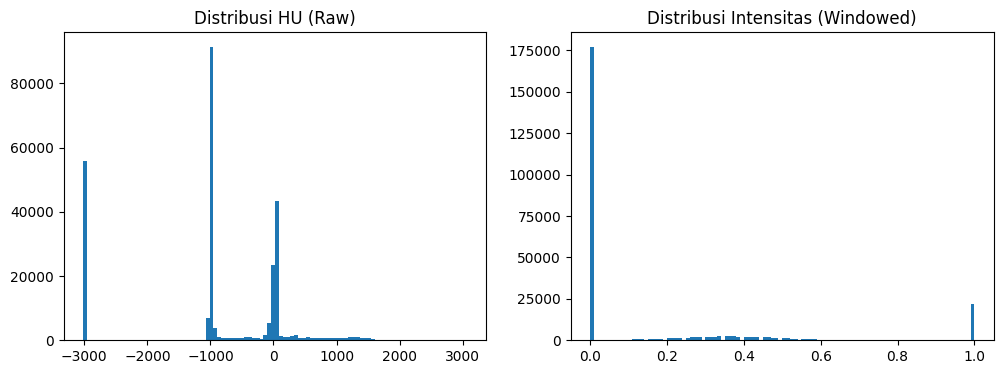

In [28]:
processor = DICOMProcessor(dataset_path)
sample_row = dataset.df.iloc[0]
sample_slice = sample_row["dicom_files"][0]

raw = processor.read_hu(sample_slice)
windowed = processor.brain_window(raw)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(raw.flatten(), bins=100)
plt.title("Distribusi HU (Raw)")

plt.subplot(1,2,2)
plt.hist(windowed.flatten(), bins=100)
plt.title("Distribusi Intensitas (Windowed)")

plt.show()


### Kelas PreprocessingPipeline

Pipeline preprocessing: resize → replikasi 3 channel (subdural/brain/bone window) → normalisasi ImageNet.

In [29]:
import cv2

class PreprocessingPipeline:
    
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    
    def __init__(self, target_size=224):
        self.target_size = target_size
    
    def resize(self, image):
        return cv2.resize(image, (self.target_size, self.target_size),
                          interpolation=cv2.INTER_LINEAR)
    
    def normalize(self, image):
        for c in range(3):
            image[c] = (image[c] - self.IMAGENET_MEAN[c]) / self.IMAGENET_STD[c]
        return image


### Fungsi Visualisasi Preprocessing

Fungsi untuk menampilkan tiap tahap preprocessing secara visual pada satu slice.

In [30]:
def visualize_preprocessing(df, processor, preprocess, 
                            study_idx=0, slice_idx=0):
    
    row = df.iloc[study_idx]
    rel_path = row["dicom_files"][slice_idx]
    
    raw = processor.read_hu(rel_path)
    windowed = processor.brain_window(raw)
    resized = preprocess.resize(windowed)
    
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    
    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Raw HU")
    axes[0].axis("off")
    
    axes[1].imshow(windowed, cmap="gray")
    axes[1].set_title("Brain Window (WL=40, WW=80)")
    axes[1].axis("off")
    
    axes[2].imshow(resized, cmap="gray")
    axes[2].set_title("Resized 224×224")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print("Windowed Range:", windowed.min(), "to", windowed.max())


### Jalankan Visualisasi Preprocessing

Menjalankan visualisasi pada slice ke-10 dari studi pertama.

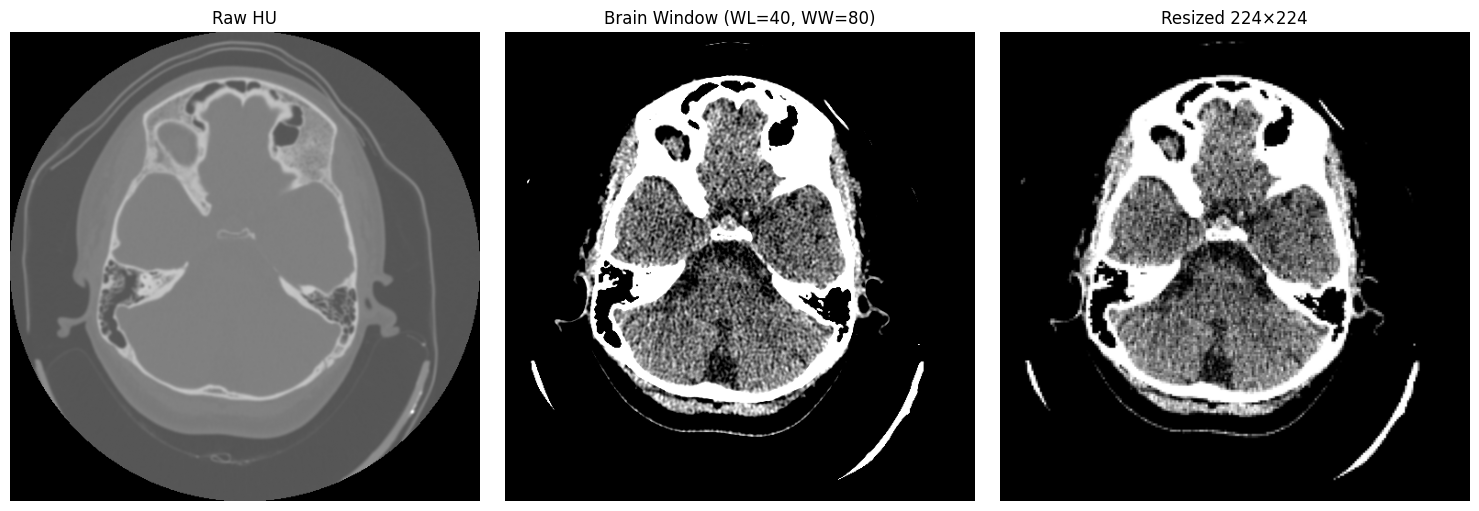

Windowed Range: 0.0 to 1.0


In [31]:
processor = DICOMProcessor(dataset_path)
preprocess = PreprocessingPipeline()

visualize_preprocessing(
    dataset.df,
    processor,
    preprocess,
    study_idx=0,
    slice_idx=10
)


## Visualisasi Contoh Kasus per Subtipe ICH

Bagian ini menampilkan contoh visual gambar CT scan untuk setiap subtipe ICH, membandingkan kasus positif dengan kasus normal, serta mengilustrasikan penggunaan multi-window CT.

### Contoh Kasus Positif vs Normal per Subtipe

Setiap baris menampilkan subtipe berbeda. Kolom kiri = kasus positif (ICH terdeteksi), kolom kanan = kasus normal. Slice yang digunakan adalah slice tengah studi untuk representasi terbaik.

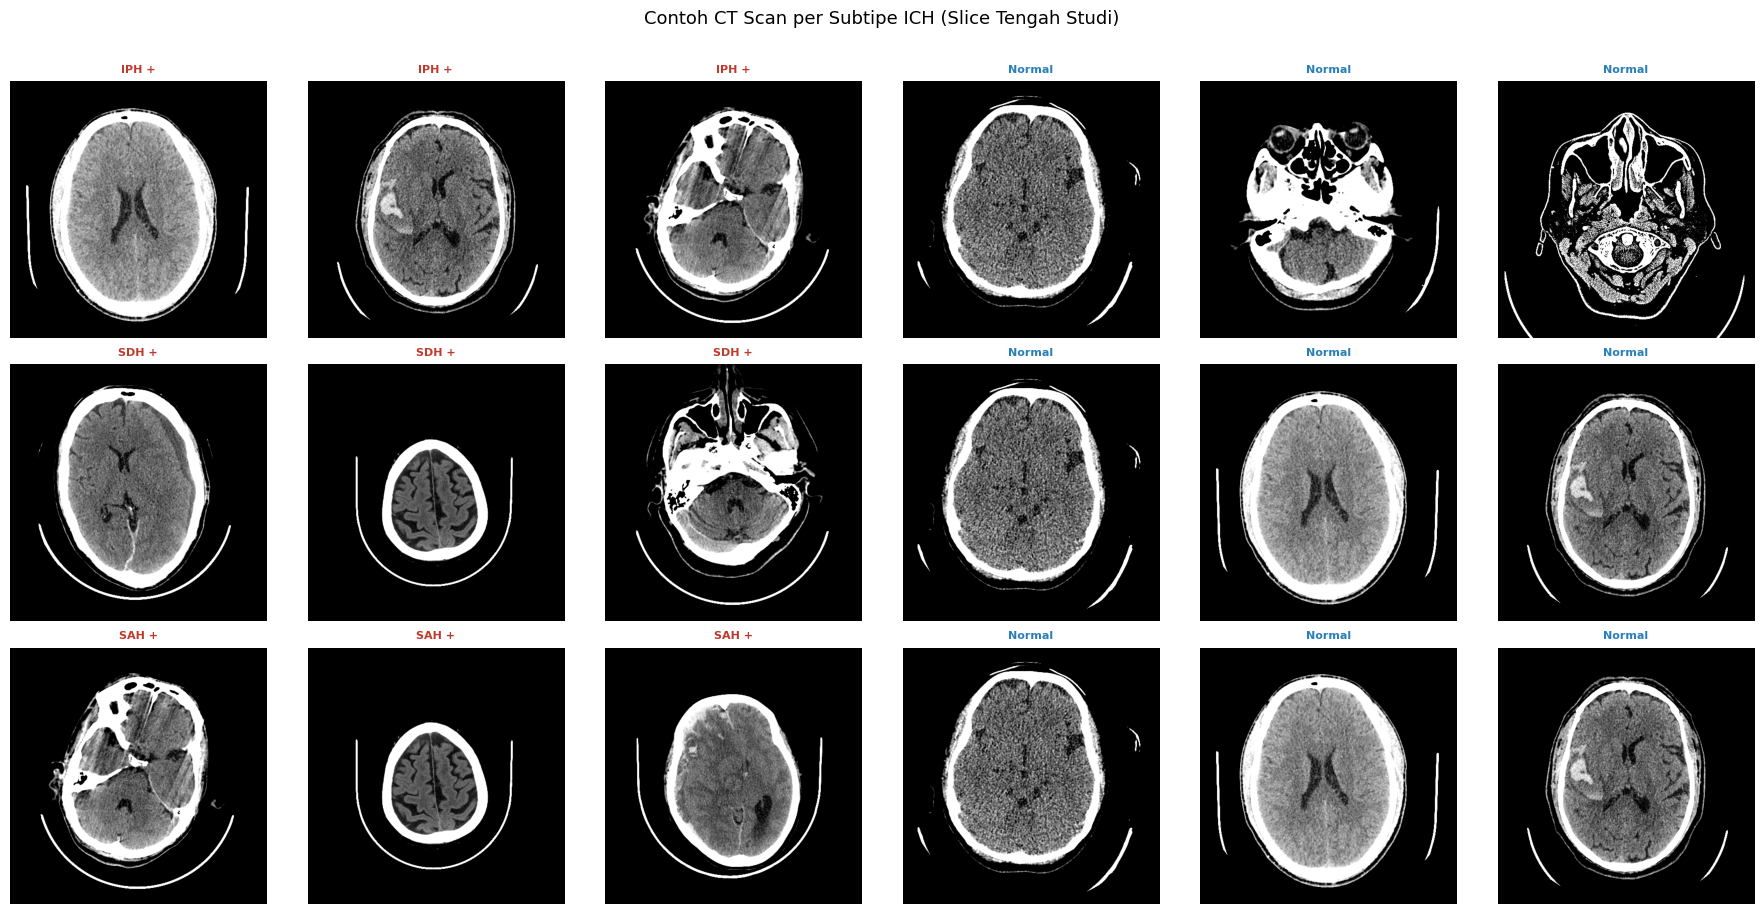

In [32]:
def show_case_examples(dataset_df, processor, subtypes, n_examples=3):
    """
    Grid visualisasi: setiap baris = 1 subtipe,
    kolom kiri = kasus positif, kolom kanan = kasus normal.
    """
    fig, axes = plt.subplots(
        len(subtypes), n_examples * 2,
        figsize=(n_examples * 2 * 3, len(subtypes) * 3)
    )
    # Pastikan axes selalu 2D
    if len(subtypes) == 1:
        axes = [axes]

    for row_idx, subtype in enumerate(subtypes):
        pos_cases = dataset_df[dataset_df[subtype] == 1].head(n_examples)
        neg_cases = dataset_df[dataset_df[subtype] == 0].head(n_examples)

        for col_idx, (_, case) in enumerate(pos_cases.iterrows()):
            mid = len(case["dicom_files"]) // 2
            img = processor.read_hu(case["dicom_files"][mid])
            img = processor.brain_window(img)
            axes[row_idx][col_idx].imshow(img, cmap="gray")
            axes[row_idx][col_idx].set_title(f"{subtype} +", fontsize=8, color="#c0392b", fontweight="bold")
            axes[row_idx][col_idx].axis("off")

        for col_idx, (_, case) in enumerate(neg_cases.iterrows()):
            mid = len(case["dicom_files"]) // 2
            img = processor.read_hu(case["dicom_files"][mid])
            img = processor.brain_window(img)
            axes[row_idx][n_examples + col_idx].imshow(img, cmap="gray")
            axes[row_idx][n_examples + col_idx].set_title("Normal", fontsize=8, color="#2980b9", fontweight="bold")
            axes[row_idx][n_examples + col_idx].axis("off")

        # Label subtipe di kiri
        axes[row_idx][0].set_ylabel(subtype, fontsize=10, fontweight="bold", rotation=90, labelpad=10)

    plt.suptitle("Contoh CT Scan per Subtipe ICH (Slice Tengah Studi)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


show_case_examples(dataset.df, processor, ["IPH", "SDH", "SAH"], n_examples=3)

### Perbandingan 3 Window CT Scan pada 1 Slice

CT scan otak dapat diinterpretasikan dengan **window** yang berbeda tergantung jaringan yang ingin dilihat. Proyek ini menggunakan ketiga window sebagai 3 channel input model, mirip dengan channel RGB pada gambar biasa.

| Window | WL | WW | Kegunaan |
|--------|----|----|----------|
| Subdural | 75 | 215 | Deteksi perdarahan subdural |
| Brain | 40 | 80 | Jaringan otak umum |
| Bone | 600 | 2800 | Struktur tulang tengkorak |

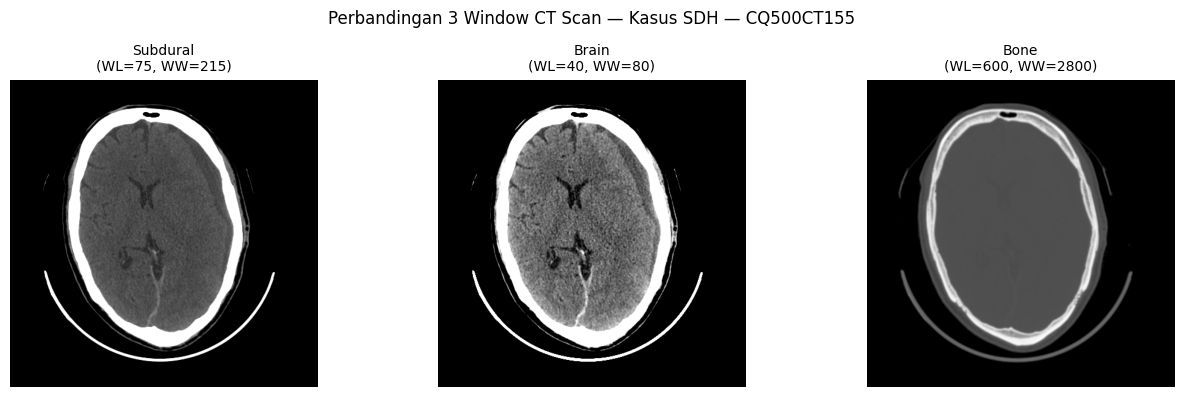

In [33]:
def show_three_windows(processor, dicom_path, title=""):
    """Tampilkan subdural / brain / bone window untuk 1 slice."""
    raw = processor.read_hu(dicom_path)

    windows = [
        ("Subdural\n(WL=75, WW=215)",  75, 215),
        ("Brain\n(WL=40, WW=80)",       40,  80),
        ("Bone\n(WL=600, WW=2800)",    600, 2800),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (name, wl, ww) in zip(axes, windows):
        hu_min = wl - ww / 2
        hu_max = wl + ww / 2
        img = np.clip(raw, hu_min, hu_max)
        img = (img - hu_min) / (hu_max - hu_min)
        ax.imshow(img, cmap="gray")
        ax.set_title(name, fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Perbandingan 3 Window CT Scan — {title}", fontsize=12)
    plt.tight_layout()
    plt.show()


# Contoh dari kasus SDH positif
sdh_case = dataset.df[dataset.df["SDH"] == 1].iloc[0]
mid_slice = sdh_case["dicom_files"][len(sdh_case["dicom_files"]) // 2]
show_three_windows(processor, mid_slice, title=f"Kasus SDH — {sdh_case['study_id']}")

### Progression Slice — Beberapa Slice dari 1 Pasien

CT scan otak terdiri dari **banyak slice berurutan** dari bawah ke atas kepala. Visualisasi ini menunjukkan bagaimana penampakan perdarahan dapat bervariasi antar slice dalam satu studi yang sama.

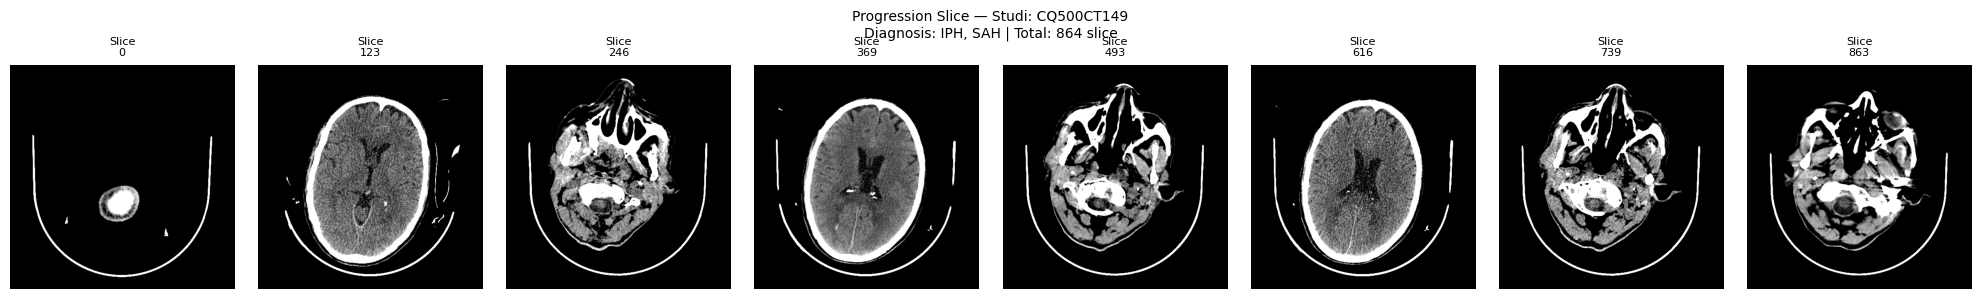

In [34]:
def show_slice_progression(processor, case_row, n_slices=8):
    """Tampilkan n_slices tersebar merata dari satu studi CT."""
    slices = case_row["dicom_files"]
    indices = np.linspace(0, len(slices) - 1, n_slices, dtype=int)

    fig, axes = plt.subplots(1, n_slices, figsize=(n_slices * 2.5, 3))
    for ax, idx in zip(axes, indices):
        img = processor.read_hu(slices[idx])
        img = processor.brain_window(img)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Slice\n{idx}", fontsize=8)
        ax.axis("off")

    diagnosis = [s for s in ["IPH", "IVH", "SDH", "EDH", "SAH"] if case_row.get(s, 0) == 1]
    label_str = ", ".join(diagnosis) if diagnosis else "Normal"
    plt.suptitle(
        f"Progression Slice — Studi: {case_row['study_id']}\n"
        f"Diagnosis: {label_str} | Total: {len(slices)} slice",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


# Contoh dari kasus ICH positif
ich_case = dataset.df[dataset.df["Any_ICH"] == 1].iloc[2]
show_slice_progression(processor, ich_case)

### Setup Folder Cache

Membuat direktori `/kaggle/working/cache` sebagai tujuan penyimpanan file `.npy`.

In [35]:
import os
import numpy as np
from tqdm import tqdm
cache_root = "/kaggle/working/cache"
os.makedirs(cache_root, exist_ok=True)

print("Cache folder:", cache_root)


Cache folder: /kaggle/working/cache


### Fungsi Build Cache

Fungsi `build_cache` yang memproses tiap slice dan menyimpannya sebagai `.npy` di disk.

In [36]:
def build_cache(dataset_df, processor, preprocess, cache_root):
    
    total_saved = 0
    
    for _, row in tqdm(dataset_df.iterrows(), total=len(dataset_df)):
        
        study_id = row["study_id"]
        dicom_list = row["dicom_files"]
        
        study_dir = os.path.join(cache_root, study_id)
        os.makedirs(study_dir, exist_ok=True)
        
        for i, dicom_path in enumerate(dicom_list):
            
            save_path = os.path.join(study_dir, f"{i}.npy")
            
            # Skip jika sudah ada (resume-safe)
            if os.path.exists(save_path):
                continue
            
            try:
                # Phase 6 pipeline
                img = processor.read_hu(dicom_path)
                img = processor.brain_window(img)
                img = preprocess.resize(img)
                
                # simpan sebagai float16 untuk hemat storage
                np.save(save_path, img.astype(np.float16))
                
                total_saved += 1
                
            except Exception as e:
                continue
    
    print("Total cached slices:", total_saved)


## 12. Build Cache ke Disk

Fungsi `build_cache` memproses seluruh dataset dan menyimpan setiap slice sebagai file `.npy` (satu folder per study) untuk mempercepat loading saat training.

In [37]:
# build_cache(dataset.df, processor, preprocess, cache_root)

## Visualisasi Hasil Augmentasi Data

Augmentasi data adalah teknik memperbanyak variasi data training secara artifisial agar model lebih **robust** dan tidak overfitting. Berikut adalah contoh transformasi yang diterapkan pada setiap gambar saat training.

### Contoh Transformasi Augmentasi

Gambar pertama adalah gambar asli. Gambar-gambar berikutnya adalah hasil augmentasi acak dengan kombinasi transformasi:

- **Horizontal Flip** — cerminan horizontal
- **Rotasi** — rotasi ±15°
- **Shift/Scale** — pergeseran dan skala ±10%
- **Gaussian Noise** — penambahan noise untuk simulasi variasi sensor
- **Brightness/Contrast** — perubahan kecerahan dan kontras ±10%
- **Elastic Deformation** — deformasi elastis ringan
- **Cutout** — penghapusan kotak kecil acak untuk regularisasi

Albumentations versi: 2.0.8 (mode: ≥2.0)


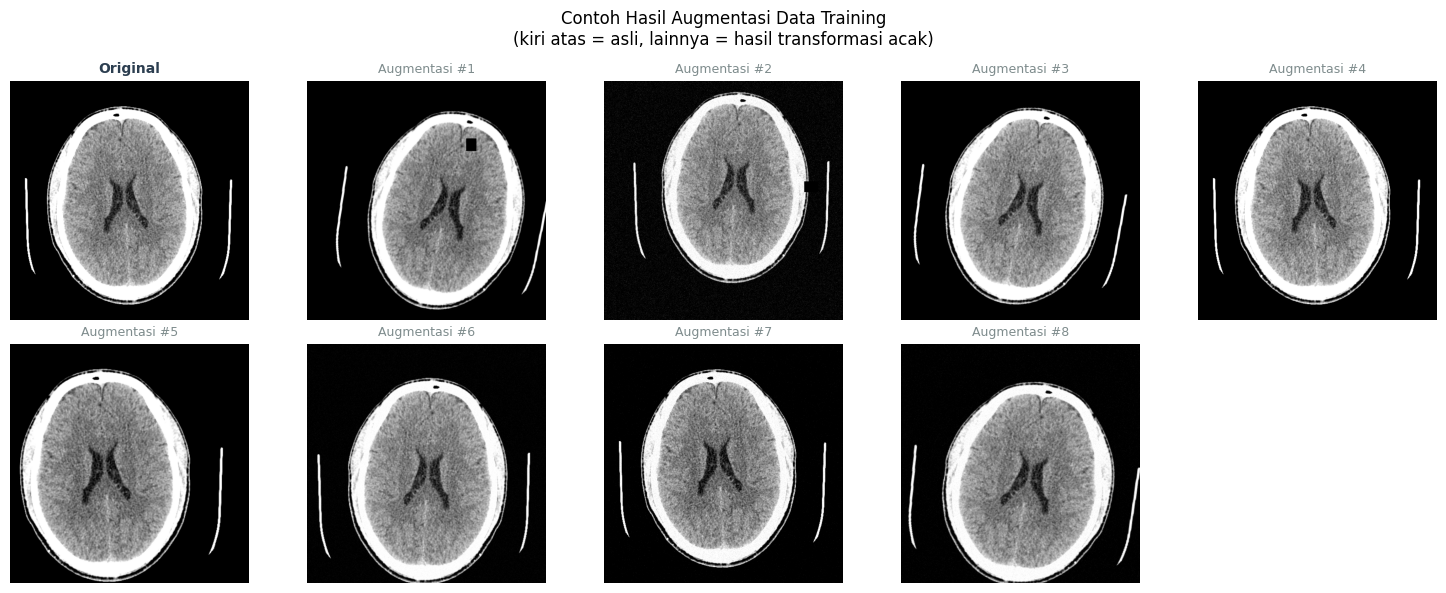

In [38]:
try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("albumentations tidak tersedia, gunakan: pip install albumentations")

if HAS_ALBUMENTATIONS:
    _albu_major = int(A.__version__.split(".")[0])

    def get_augmentation_pipeline():
        if _albu_major >= 2:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=15, p=0.7),
                A.Affine(translate_percent=(-0.1, 0.1), scale=(0.9, 1.1), p=0.5),
                A.GaussNoise(std_range=(0.001, 0.07), p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
                A.ElasticTransform(alpha=1.0, sigma=50.0, p=0.3),
                A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(10, 30), hole_width_range=(10, 30), p=0.3),
            ])
        else:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=15, p=0.7),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5),
                A.GaussNoise(var_limit=(0.001, 0.005), p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
                A.ElasticTransform(alpha=1, sigma=10, p=0.3),
                A.CoarseDropout(max_holes=2, max_height=30, max_width=30, p=0.3),
            ])

    def show_augmentation_examples(processor, dicom_path, n_augmented=8):
        """Tampilkan gambar asli + n_augmented hasil augmentasi."""
        raw = processor.read_hu(dicom_path)
        original = processor.brain_window(raw)
        original_uint8 = (original * 255).astype(np.uint8)

        aug = get_augmentation_pipeline()

        n_cols = (n_augmented + 2) // 2
        fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))
        axes = axes.flatten()

        axes[0].imshow(original, cmap="gray")
        axes[0].set_title("Original", fontweight="bold", fontsize=10, color="#2c3e50")
        axes[0].axis("off")
        for spine in axes[0].spines.values():
            spine.set_edgecolor("#e74c3c")
            spine.set_linewidth(2)

        for i in range(1, n_augmented + 1):
            augmented = aug(image=original_uint8)["image"]
            axes[i].imshow(augmented, cmap="gray")
            axes[i].set_title(f"Augmentasi #{i}", fontsize=9, color="#7f8c8d")
            axes[i].axis("off")

        for j in range(n_augmented + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(
            "Contoh Hasil Augmentasi Data Training\n"
            "(kiri atas = asli, lainnya = hasil transformasi acak)",
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

    print(f"Albumentations versi: {A.__version__} (mode: {'≥2.0' if _albu_major >= 2 else '1.x'})")

    ich_aug_case = dataset.df[dataset.df["Any_ICH"] == 1].iloc[0]
    mid_aug = ich_aug_case["dicom_files"][len(ich_aug_case["dicom_files"]) // 2]
    show_augmentation_examples(processor, mid_aug, n_augmented=8)


### Verifikasi File Cache

Menghitung total file `.npy` yang berhasil disimpan untuk memastikan tidak ada yang terlewat.

In [39]:
# import glob

# cached_files = glob.glob(cache_root + "/**/*.npy", recursive=True)

# print("Total cached files:", len(cached_files))


### Kompresi Cache ke TAR

Mengompresi seluruh folder cache menjadi satu file `cache.tar` untuk kemudahan upload.

In [40]:
# !tar -cf /kaggle/working/cache.tar -C /kaggle/working cache

### Pindahkan TAR ke Folder Upload

Membuat folder tujuan upload dan memindahkan `cache.tar` ke dalamnya.

In [41]:

# Buat foldernya dulu jika belum ada
# !mkdir -p /kaggle/working/cq500_dataset_upload/

# Pindahkan filenya
# !mv /kaggle/working/cache.tar /kaggle/working/cq500_dataset_upload/

### Pindahkan File PKL

Memindahkan file metadata dan splits (`.pkl`) ke folder upload.

In [42]:
# !mv /kaggle/working/cache/*.pkl /kaggle/working/cq500_dataset_upload/

### Verifikasi Isi Folder Upload

Menampilkan daftar dan ukuran file yang siap diupload.

In [43]:
# !ls -lh /kaggle/working/cq500_dataset_upload


## 13. Persiapan Folder Upload

Memindahkan `cache.tar` dan file `.pkl` ke satu folder untuk siap diupload ke Kaggle.

In [44]:
# import json

# USERNAME = "tsyaidfarhan"   # ← ganti dengan username Kaggle Anda

# metadata = {
#     "title": "CQ500 Preprocessed Cache",
#     "id": f"{USERNAME}/cq500-preprocessed-cache",
#     "licenses": [{"name": "CC0-1.0"}]
# }

# with open("/kaggle/working/cq500_dataset_upload/dataset-metadata.json", "w") as f:
#     json.dump(metadata, f)

# print("Metadata created.")


## 14. Upload Dataset ke Kaggle API

Membuat metadata JSON (`dataset-metadata.json`) dan mengupload dataset ke Kaggle menggunakan Kaggle CLI.

In [45]:
# import os
# import shutil

# 1. Lokasi file yang baru saja Anda upload
# source = '/kaggle/input/datasets/tsyaidfarhan/my-api/kaggle.json'

# 2. Lokasi tujuan yang diminta sistem
# dest_dir = '/root/.config/kaggle'
# dest_file = os.path.join(dest_dir, 'kaggle.json')

# 3. Buat folder tujuan dan pindahkan filenya
# os.makedirs(dest_dir, exist_ok=True)
# shutil.copy(source, dest_file)

# 4. Atur izin akses (WAJIB: API Kaggle akan error jika permission-nya terlalu terbuka)
# os.chmod(dest_file, 0o600)

# print("Keren! kaggle.json sudah terpasang dengan benar.")

### Upload Dataset ke Kaggle

Membuat dataset baru di Kaggle menggunakan `kaggle datasets create`.

In [46]:
# !kaggle datasets create -p /kaggle/working/cq500_dataset_upload --dir-mode zip


### Perbarui Versi Dataset

Memperbarui versi dataset yang sudah ada di Kaggle.

In [47]:
# !kaggle datasets version -p /kaggle/working/cq500_dataset_upload -m "Update cache"

## 15. Akses Dataset yang Sudah Diupload

Ekstrak cache dari Kaggle input dataset dan load splits untuk digunakan di notebook training.

In [48]:
# !tar -xf /kaggle/input/cq500-preprocessed-cache/cache.tar -C /kaggle/working/

### Load Splits dari Dataset

Memuat file `cq500_splits.pkl` dari dataset yang telah diupload.

In [49]:
# import pickle

# with open(SPLITS_PATH, "rb") as f:
#     splits = pickle.load(f)

### Definisi Path untuk Training

Mendefinisikan `CACHE_ROOT` dan `SPLITS_PATH` yang akan digunakan di notebook training.

In [50]:
# DATASET_NAME = "cq500-preprocessed-cache"  # ganti jika beda

# DATA_ROOT = f"/kaggle/input/{DATASET_NAME}"

# CACHE_ROOT = DATA_ROOT + "/cache"
# SPLITS_PATH = DATA_ROOT + "/splits.pkl"

## 17. Scheduler & Kode Arsip

Fungsi learning rate scheduler dengan linear warmup + cosine decay. Blok validasi lama disimpan sebagai referensi.

In [51]:
# import numpy as np

# def get_scheduler(optimizer, total_steps, warmup_steps):
    
#     def lr_lambda(step):
#         if step < warmup_steps:
#             return step / warmup_steps
#         progress = (step - warmup_steps) / (total_steps - warmup_steps)
#         return 0.5 * (1 + np.cos(np.pi * progress))
    
#     return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


### (Diarsipkan) Kode Validasi Lama

Blok validasi patient-level yang dikomentari — dipertahankan sebagai referensi historis.

In [52]:
# from collections import defaultdict
# from sklearn.metrics import roc_auc_score

# def validate_patient_level(model, val_loader, device, k=5):
    
#     model.eval()
    
#     from collections import defaultdict
#     slice_dict = defaultdict(list)
#     labels = {}
    
#     with torch.no_grad():
        
#         idx = 0
        
#         for images, batch_labels in val_loader:
            
#             images = images.to(device)
#             probs = torch.sigmoid(model(images)).cpu().numpy()
            
#             for i in range(len(probs)):
                
#                 study_id = val_loader.dataset.samples[idx][2]
                
#                 slice_dict[study_id].append(probs[i])
#                 labels[study_id] = batch_labels[i].item()
                
#                 idx += 1
    
#     y_true, y_pred = [], []
    
#     for sid in slice_dict:
#         topk = sorted(slice_dict[sid], reverse=True)[:k]
#         y_pred.append(np.mean(topk))
#         y_true.append(labels[sid])
    
#     return roc_auc_score(y_true, y_pred)

